# Session 3 - Cross-Validation, Hyperparameter Tuning & Model Diagnostics

Goal: use K-Fold cross-validation and GridSearchCV to choose Ridge/Lasso alpha more systematically, then inspect the best model with residual and learning-curve diagnostics.

## 1. Key Concepts

- A single 80/20 train/test split can be lucky or unlucky, especially when the dataset is not very large.
- K-Fold CV splits the data into K folds, trains K times, and reports the average validation score.
- GridSearchCV tries multiple hyperparameter values and chooses the one with the best CV score.
- Residuals are `actual - predicted`; random residuals around 0 are usually healthier than a visible pattern.
- Learning curves compare train and validation error as training size grows, which helps diagnose overfit or underfit.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, learning_curve, train_test_split

## 2. Set Up Paths And Import Preprocessing

In [2]:
PROJECT_DIR = Path.cwd()

if PROJECT_DIR.name == "model_training":
    PROJECT_DIR = PROJECT_DIR.parents[1]
elif PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
elif (PROJECT_DIR / "my-project").exists():
    PROJECT_DIR = PROJECT_DIR / "my-project"

SRC_DIR = PROJECT_DIR / "src"
DATA_PATH = PROJECT_DIR / "data" / "raw" / "train.csv"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
PREPROCESSOR_PATH = ARTIFACTS_DIR / "preprocessor_cv_tuning.pkl"

sys.path.insert(0, str(SRC_DIR))

from ml.preprocessing import preprocess_train

print(f"Project dir: {PROJECT_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Preprocessor artifact: {PREPROCESSOR_PATH}")

Project dir: c:\Users\ADMIN\OneDrive - The University of Technology\Documents\Intern AgilityIO\internship-hoaihuynh-training\my-project
Data path: c:\Users\ADMIN\OneDrive - The University of Technology\Documents\Intern AgilityIO\internship-hoaihuynh-training\my-project\data\raw\train.csv
Preprocessor artifact: c:\Users\ADMIN\OneDrive - The University of Technology\Documents\Intern AgilityIO\internship-hoaihuynh-training\my-project\artifacts\preprocessor_cv_tuning.pkl


## 3. Load Raw Data And Split Target

This notebook keeps the same raw data source and log target transform as Sessions 1 and 2.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing training data: {DATA_PATH}. "
        "Place Kaggle House Prices train.csv under my-project/data/raw/ first."
    )

df_raw = pd.read_csv(DATA_PATH)

if "SalePrice" not in df_raw.columns:
    raise ValueError("Expected target column `SalePrice` in train.csv")

y_price = df_raw["SalePrice"]
x_raw = df_raw.drop(columns=["SalePrice"])

print(f"Raw feature shape: {x_raw.shape}")
print(f"Target shape: {y_price.shape}")
display(df_raw.head())

Raw feature shape: (1460, 80)
Target shape: (1460,)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 4. Reuse Session 1-2 Feature Set

Keeping the same feature set makes the Session 3 CV/GridSearch results directly comparable with earlier single-split results.

In [4]:
num_cols = ["LotFrontage", "MasVnrArea", "TotalBsmtSF"]
cat_cols = ["GarageType", "Alley"]
ord_cols = ["ExterQual"]

selected_cols = num_cols + cat_cols + ord_cols
missing_cols = [col for col in selected_cols if col not in x_raw.columns]

if missing_cols:
    raise ValueError(f"Missing selected columns in train.csv: {missing_cols}")

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Ordinal columns:", ord_cols)

Numeric columns: ['LotFrontage', 'MasVnrArea', 'TotalBsmtSF']
Categorical columns: ['GarageType', 'Alley']
Ordinal columns: ['ExterQual']


## 5. Preprocess Features And Transform Target

The target is transformed with `log1p` so RMSE is measured on the same scale as Sessions 1 and 2.

In [5]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

x_processed = preprocess_train(
    df=x_raw,
    num_cols=num_cols,
    cat_cols=cat_cols,
    ord_cols=ord_cols,
    save_path=str(PREPROCESSOR_PATH),
)
y_log = np.log1p(y_price)

print(f"Processed X shape: {x_processed.shape}")
print(f"Log target shape: {y_log.shape}")
print(f"Saved preprocessor: {PREPROCESSOR_PATH.exists()}")

Processed X shape: (1460, 14)
Log target shape: (1460,)
Saved preprocessor: True


## 6. Single Split Baseline

This repeats the 80/20 style evaluation so we can compare it with CV. These numbers can change if the split changes.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    x_processed,
    y_log,
    test_size=0.2,
    random_state=42,
)


def evaluate_single_split(model, model_name: str) -> dict[str, float | str]:
    """Fit a model and return holdout metrics on the log-transformed target."""
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    y_pred_log = fitted_model.predict(X_test)

    return {
        "model": model_name,
        "rmse_log": np.sqrt(mean_squared_error(y_test, y_pred_log)),
        "mae_log": mean_absolute_error(y_test, y_pred_log),
        "r2": r2_score(y_test, y_pred_log),
    }


single_split_results = pd.DataFrame(
    [
        evaluate_single_split(Ridge(alpha=10.0), "Ridge(alpha=10.0)"),
        evaluate_single_split(Lasso(alpha=0.01, max_iter=20000), "Lasso(alpha=0.01)"),
    ]
)

display(single_split_results)

,model,rmse_log,mae_log,r2
0,Ridge(alpha=10.0),0.246174,0.175697,0.675251
1,Lasso(alpha=0.01),0.254712,0.184779,0.652335


## 7. K-Fold Cross-Validation

`cross_val_score` returns one score per fold. With `neg_root_mean_squared_error`, sklearn returns negative values because higher scores are considered better, so multiply by `-1` to read RMSE.

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)


def cross_validate_rmse(model, model_name: str) -> dict[str, float | str]:
    """Return K-Fold RMSE summary for a model."""
    fold_rmse = -cross_val_score(
        model,
        x_processed,
        y_log,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    return {
        "model": model_name,
        "cv_rmse_mean": fold_rmse.mean(),
        "cv_rmse_std": fold_rmse.std(),
        "fold_1": fold_rmse[0],
        "fold_2": fold_rmse[1],
        "fold_3": fold_rmse[2],
        "fold_4": fold_rmse[3],
        "fold_5": fold_rmse[4],
    }


cv_results = pd.DataFrame(
    [
        cross_validate_rmse(Ridge(alpha=10.0), "Ridge(alpha=10.0)"),
        cross_validate_rmse(Lasso(alpha=0.01, max_iter=20000), "Lasso(alpha=0.01)"),
    ]
)

display(cv_results)

,model,cv_rmse_mean,cv_rmse_std,fold_1,fold_2,fold_3,fold_4,fold_5
0,Ridge(alpha=10.0),0.251958,0.022257,0.246174,0.233941,0.290644,0.260509,0.228524
1,Lasso(alpha=0.01),0.260006,0.021437,0.254712,0.243759,0.293253,0.274544,0.233760


## 8. Compare Single Split With CV

If single-split RMSE and average CV RMSE are far apart, the single split may have been optimistic or pessimistic.

In [8]:
split_vs_cv = single_split_results.merge(
    cv_results[["model", "cv_rmse_mean", "cv_rmse_std"]],
    on="model",
)
split_vs_cv["single_minus_cv_rmse"] = split_vs_cv["rmse_log"] - split_vs_cv["cv_rmse_mean"]

display(split_vs_cv)

,model,rmse_log,mae_log,r2,cv_rmse_mean,cv_rmse_std,single_minus_cv_rmse
0,Ridge(alpha=10.0),0.246174,0.175697,0.675251,0.251958,0.022257,-0.005784
1,Lasso(alpha=0.01),0.254712,0.184779,0.652335,0.260006,0.021437,-0.005294


## 9. GridSearchCV For Alpha

GridSearchCV tests each alpha with the same 5-fold CV setup and chooses the alpha with the lowest average validation RMSE.

In [9]:
alpha_grid = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid={"alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
lasso_search = GridSearchCV(
    estimator=Lasso(max_iter=20000),
    param_grid={"alpha": alpha_grid},
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

ridge_search.fit(x_processed, y_log)
lasso_search.fit(x_processed, y_log)


def summarize_search(search: GridSearchCV, model_name: str) -> dict[str, float | str]:
    """Return the best alpha and readable RMSE score from GridSearchCV."""
    return {
        "model": model_name,
        "best_alpha": search.best_params_["alpha"],
        "best_cv_rmse_log": -search.best_score_,
    }


grid_summary = pd.DataFrame(
    [
        summarize_search(ridge_search, "Ridge"),
        summarize_search(lasso_search, "Lasso"),
    ]
).sort_values("best_cv_rmse_log")

display(grid_summary)

,model,best_alpha,best_cv_rmse_log
0,Ridge,1.000,0.251558
1,Lasso,0.001,0.252076


## 10. Inspect Grid Search Curves

,model,alpha,mean_train_rmse_log,mean_cv_rmse_log,std_cv_rmse_log
0,Ridge,0.001,0.243807,0.251604,0.022128
1,Ridge,0.003,0.243807,0.251604,0.022128
2,Ridge,0.010,0.243807,0.251603,0.022128
3,Ridge,0.030,0.243807,0.251602,0.022128
4,Ridge,0.100,0.243807,0.251597,0.022129
5,Ridge,0.300,0.243808,0.251585,0.022132
6,Ridge,1.000,0.243825,0.251558,0.022145
7,Ridge,3.000,0.243932,0.251566,0.022188
8,Ridge,10.000,0.244561,0.251958,0.022257
9,Ridge,30.000,0.246842,0.253810,0.022076


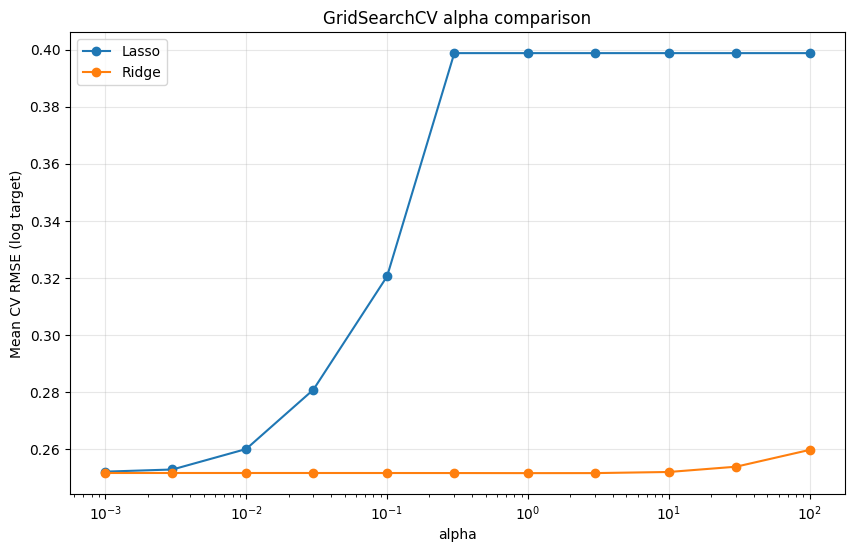

In [10]:
def search_results_frame(search: GridSearchCV, model_name: str) -> pd.DataFrame:
    """Convert GridSearchCV results into a compact RMSE table."""
    results = pd.DataFrame(search.cv_results_)
    return pd.DataFrame(
        {
            "model": model_name,
            "alpha": results["param_alpha"].astype(float),
            "mean_train_rmse_log": -results["mean_train_score"],
            "mean_cv_rmse_log": -results["mean_test_score"],
            "std_cv_rmse_log": results["std_test_score"],
        }
    ).sort_values("alpha")


ridge_grid_results = search_results_frame(ridge_search, "Ridge")
lasso_grid_results = search_results_frame(lasso_search, "Lasso")
all_grid_results = pd.concat([ridge_grid_results, lasso_grid_results], ignore_index=True)

display(all_grid_results)

fig, ax = plt.subplots(figsize=(10, 6))

for model_name, model_results in all_grid_results.groupby("model"):
    ax.plot(
        model_results["alpha"],
        model_results["mean_cv_rmse_log"],
        marker="o",
        label=model_name,
    )

ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("Mean CV RMSE (log target)")
ax.set_title("GridSearchCV alpha comparison")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 11. Choose Final Model

The final model is selected by the lowest average CV RMSE, not by manually eyeballing one split.

In [11]:
best_model_name = grid_summary.iloc[0]["model"]

if best_model_name == "Ridge":
    final_model = clone(ridge_search.best_estimator_)
    final_alpha = ridge_search.best_params_["alpha"]
    final_cv_rmse = -ridge_search.best_score_
else:
    final_model = clone(lasso_search.best_estimator_)
    final_alpha = lasso_search.best_params_["alpha"]
    final_cv_rmse = -lasso_search.best_score_

final_single_split_metrics = evaluate_single_split(
    final_model,
    f"{best_model_name}(alpha={final_alpha})",
)

final_summary = pd.DataFrame(
    [
        {
            "final_model": best_model_name,
            "final_alpha": final_alpha,
            "best_cv_rmse_log": final_cv_rmse,
            "holdout_rmse_log": final_single_split_metrics["rmse_log"],
            "holdout_mae_log": final_single_split_metrics["mae_log"],
            "holdout_r2": final_single_split_metrics["r2"],
        }
    ]
)

display(final_summary)

,final_model,final_alpha,best_cv_rmse_log,holdout_rmse_log,holdout_mae_log,holdout_r2
0,Ridge,1,0.251558,0.247435,0.176409,0.671915


## 12. Residual Plot

Residuals should ideally look randomly scattered around 0. A curve, funnel, or clear band can mean the model is missing structure.

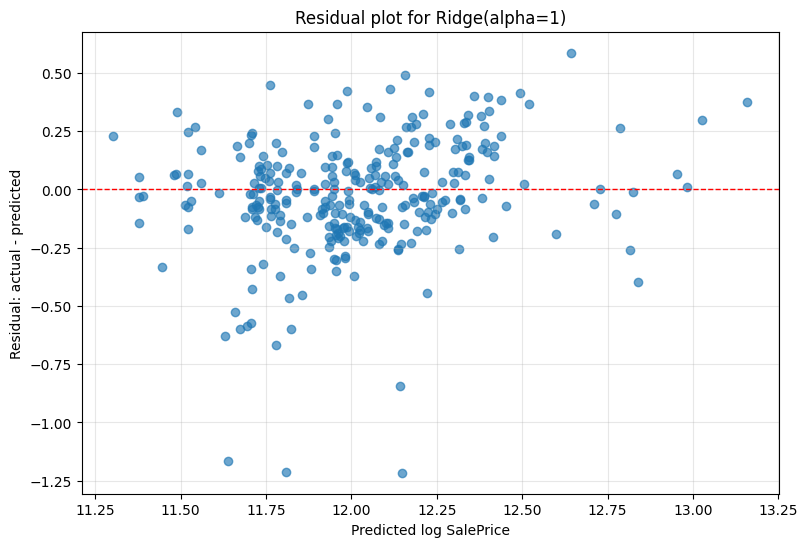

count    292.000000
mean      -0.023942
std        0.246697
min       -1.215599
25%       -0.145298
50%       -0.019573
75%        0.121119
max        0.586665
Name: SalePrice, dtype: float64

In [12]:
final_model.fit(X_train, y_train)
holdout_pred_log = final_model.predict(X_test)
residuals = y_test - holdout_pred_log

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(holdout_pred_log, residuals, alpha=0.65)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted log SalePrice")
ax.set_ylabel("Residual: actual - predicted")
ax.set_title(f"Residual plot for {best_model_name}(alpha={final_alpha})")
ax.grid(True, alpha=0.3)
plt.show()

residual_summary = pd.Series(residuals).describe()
display(residual_summary)

## 13. Learning Curve

- Overfit pattern: train RMSE stays low while validation RMSE stays much higher.
- Underfit pattern: both train and validation RMSE are high and close together.
- Healthier pattern: validation RMSE improves with more data and the gap is not too large.

,train_size,train_rmse_mean,train_rmse_std,validation_rmse_mean,validation_rmse_std
0,116,0.216788,0.007428,0.257800,0.020453
1,327,0.227759,0.007699,0.252187,0.022484
2,537,0.240807,0.002266,0.252114,0.022630
3,747,0.240814,0.003157,0.252111,0.021885
4,957,0.237066,0.003114,0.250123,0.022632
5,1168,0.243825,0.004744,0.251558,0.022145


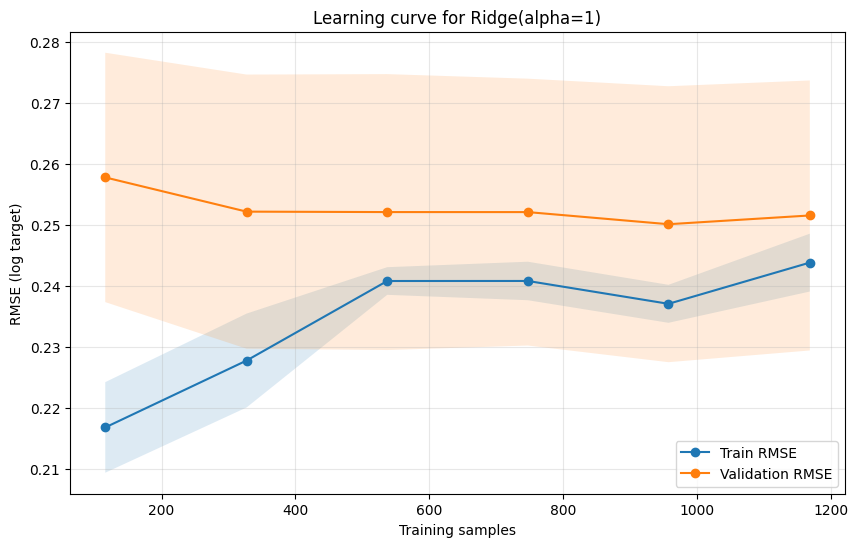

In [13]:
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=clone(final_model),
    X=x_processed,
    y=y_log,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std = train_scores.std(axis=1)
validation_rmse_mean = -validation_scores.mean(axis=1)
validation_rmse_std = validation_scores.std(axis=1)

learning_curve_results = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_rmse_mean": train_rmse_mean,
        "train_rmse_std": train_rmse_std,
        "validation_rmse_mean": validation_rmse_mean,
        "validation_rmse_std": validation_rmse_std,
    }
)

display(learning_curve_results)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_rmse_mean, marker="o", label="Train RMSE")
ax.fill_between(
    train_sizes,
    train_rmse_mean - train_rmse_std,
    train_rmse_mean + train_rmse_std,
    alpha=0.15,
)
ax.plot(train_sizes, validation_rmse_mean, marker="o", label="Validation RMSE")
ax.fill_between(
    train_sizes,
    validation_rmse_mean - validation_rmse_std,
    validation_rmse_mean + validation_rmse_std,
    alpha=0.15,
)
ax.set_xlabel("Training samples")
ax.set_ylabel("RMSE (log target)")
ax.set_title(f"Learning curve for {best_model_name}(alpha={final_alpha})")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 14. Session Summary

- Used 5-fold cross-validation to reduce dependence on one lucky or unlucky split.
- Used GridSearchCV to choose alpha systematically for Ridge and Lasso.
- Selected the final model by lowest CV RMSE on the log target.
- Used residual and learning-curve plots to diagnose model behavior beyond one RMSE number.
- Based on the current data and feature set, the final production candidate for Session 4 is the model shown in `final_summary`.